In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.linalg import toeplitz
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from functions import *

plt.rcParams.update({'font.size': 12})

In [11]:
co2_full = pd.read_csv("data/co2.dat", skiprows=16, delimiter=' ')
co2 = co2_full[82:]

In [12]:
# Define the exponential function
def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit the exponential function to the data
popt, pcov = curve_fit(exponential, co2['year'].values, co2['value'].values, p0=(0.00001, 0.01, 300), maxfev=10000)

# Extract the optimized parameters
a_opt_exp = popt[0]
b_opt_exp = popt[1]
c_opt_exp = popt[2]

# Print the parameters
print(f"a: {a_opt_exp}, b: {b_opt_exp}, c: {c_opt_exp}")
trend_exp =  exponential(co2['year'].values, a_opt_exp, b_opt_exp, c_opt_exp)

# Calculate the fit and subtract it from the actual values
co2['fit exp'] = co2['value'].values - trend_exp

a: 3.428545448518582e-09, b: 0.01222680817794814, c: 226.21021912618824


C:\Users\Tadej\AppData\Local\Temp\ipykernel_234016\2999953277.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2['fit exp'] = co2['value'].values - trend_exp


In [13]:
def linear(x, a, b):
    return a*x + b

popt, pcov = curve_fit(linear, co2['year'].values, co2['value'].values)
a_opt_linear = popt[0]
b_opt_linear = popt[1]

print(a_opt_linear)
print(b_opt_linear)

trend_linear = linear(co2['year'].values, a_opt_linear, b_opt_linear)

co2['fit linear'] = co2['value'].values - trend_linear

1.4570313368160404
-2545.7740372686176


C:\Users\Tadej\AppData\Local\Temp\ipykernel_234016\1284869334.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2['fit linear'] = co2['value'].values - trend_linear


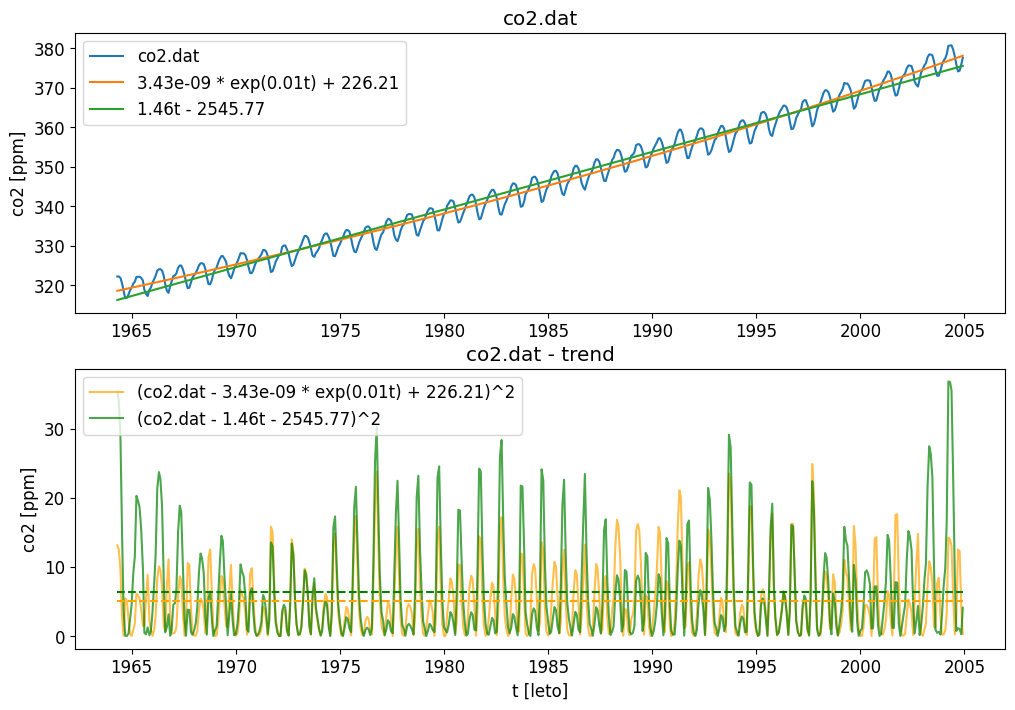

In [14]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('co2.dat')
ax.set_ylabel('co2 [ppm]')
ax.plot(co2['year'].values, co2['value'].values, label='co2.dat')
ax.plot(co2['year'].values, trend_exp, 
        label=f'{a_opt_exp:.2e} * exp({b_opt_exp:.2f}t) + {c_opt_exp:.2f}')
ax.plot(co2['year'].values, trend_linear, 
        label=f'{a_opt_linear:.2f}t - {np.abs(b_opt_linear):.2f}')
ax.legend()

diff_exp = (co2['value'].values - trend_exp)**2
MSE_exp = np.ones_like(diff_exp) * np.mean(diff_exp)

diff_linear = (co2['value'].values - trend_linear)**2
MSE_linear = np.ones_like(diff_linear) * np.mean(diff_linear)

ax = fig.add_subplot(2, 1, 2)
ax.set_title('co2.dat - trend')
ax.set_ylabel('co2 [ppm]')
ax.set_xlabel('t [leto]')
ax.plot(co2['year'].values, diff_exp, color='orange',
        label=f'(co2.dat - {a_opt_exp:.2e} * exp({b_opt_exp:.2f}t) + {c_opt_exp:.2f})^2', alpha=0.7)
ax.plot(co2['year'].values, diff_linear, color='green',
        label=f'(co2.dat - {a_opt_linear:.2f}t - {np.abs(b_opt_linear):.2f})^2', alpha=0.7)
ax.plot(co2['year'].values, MSE_exp, ls='--', color='orange')
ax.plot(co2['year'].values, MSE_linear, ls='--', color='green')
ax.legend(loc='upper left')


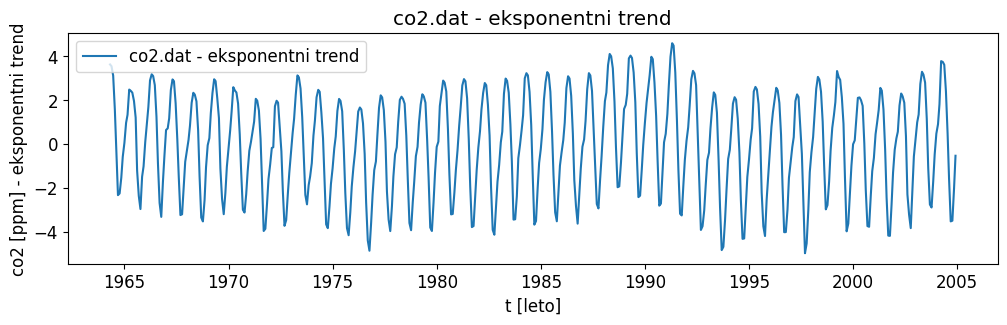

In [15]:
fig = plt.figure(figsize=(12, 3))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('co2.dat - eksponentni trend')
ax.set_ylabel('co2 [ppm] - eksponentni trend')
ax.set_xlabel('t [leto]')
ax.plot(co2['year'].values, co2['value'].values - trend_exp, label='co2.dat - eksponentni trend')
ax.legend()

In [16]:
N = len(co2['year'].values)
dt = co2['year'].values[1] - co2['year'].values[0]

nuc = 1. / (2. * dt)
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi
dnu = nus[1]-nus[0]

omegas = np.linspace(0., np.pi, round(N/2))

S, P = DFT(co2['fit exp'].values)
poles, adjusted_poles, P_MESE_10 = MESE(omegas, co2['fit exp'].values, 10, 'Reflect')
poles, adjusted_poles, P_MESE_15 = MESE(omegas, co2['fit exp'].values, 15, 'Reflect')
poles, adjusted_poles, P_MESE_20 = MESE(omegas, co2['fit exp'].values, 20, 'Reflect')
poles, adjusted_poles, P_MESE_25 = MESE(omegas, co2['fit exp'].values, 25, 'Reflect')
poles, adjusted_poles, P_MESE_35 = MESE(omegas, co2['fit exp'].values, 30, 'Reflect')

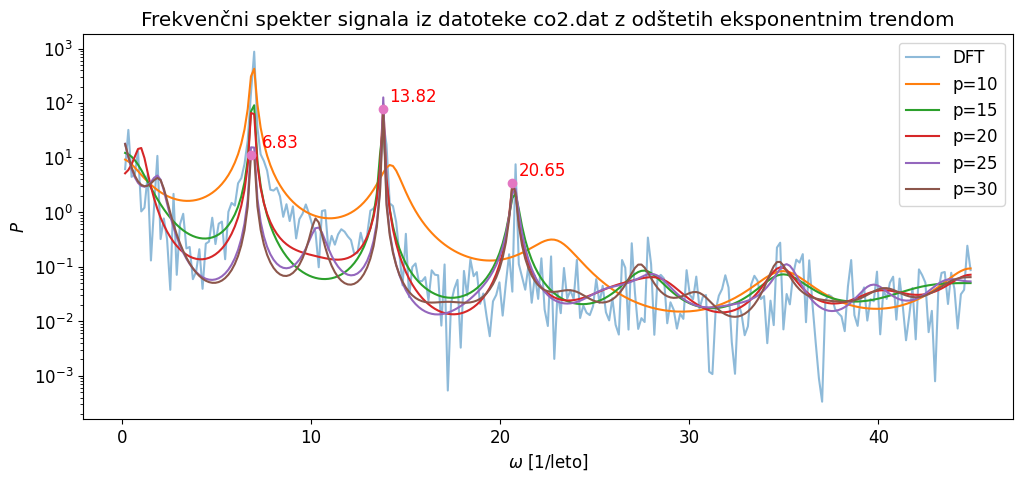

In [17]:
fig = plt.figure(figsize=(12, 5))

# Find peaks for the p=35 spectrum
peaks_mese_35, _ = find_peaks(P_MESE_35[1:], height=1)

# Plot
ax = fig.add_subplot(1, 1, 1)
ax.set_title(r'Frekvenčni spekter signala iz datoteke co2.dat z odštetih eksponentnim trendom')
ax.set_xlabel(r'$\omega$ [1/leto]')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus[1:], P[1:], label='DFT', alpha=0.5)
ax.plot(nus[1:], P_MESE_10[1:], label='p=10')
ax.plot(nus[1:], P_MESE_15[1:], label='p=15')
ax.plot(nus[1:], P_MESE_20[1:], label='p=20')
ax.plot(nus[1:], P_MESE_25[1:], label='p=25')
ax.plot(nus[1:], P_MESE_35[1:], label='p=30')

# Mark peaks
ax.plot(nus[1:][peaks_mese_35[1:]], P_MESE_35[1:][peaks_mese_35[1:]], 'o')

# Annotate peaks with omega values
for peak in peaks_mese_35[1:]:
    omega = nus[1:][peak]  # Get the corresponding omega value
    ax.annotate(
        f'{omega:.2f}',  # Format omega to two decimals
        (nus[1:][peak] + 1.2, P_MESE_35[1:][peak]),  # Peak position
        textcoords="offset points",  # Positioning
        xytext=(5, 5),  # Offset text by (x, y)
        ha='center', fontsize=12, color='red'
    )

ax.legend()
plt.show()


In [18]:
# Future prediction

co2_fit = co2['fit exp'].values[:256]

poles, adjusted_poles, co2_predict_10 = predict(co2_fit, 10, 273, 'Reflect')
poles, adjusted_poles, co2_predict_15 = predict(co2_fit, 15, 273, 'Reflect')
poles, adjusted_poles, co2_predict_20 = predict(co2_fit, 20, 273, 'Reflect')
poles, adjusted_poles, co2_predict_25 = predict(co2_fit, 25, 273, 'Reflect')
poles, adjusted_poles, co2_predict_30 = predict(co2_fit, 30, 273, 'Reflect')

poles, adjusted_poles, co2_predict = predict(co2_fit, 25, 273, 'Reflect') # 39 max brez preslikavanja polov

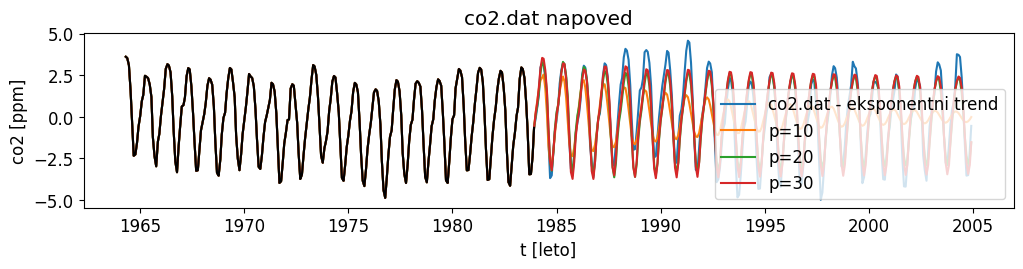

In [20]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('co2.dat napoved')
ax.set_ylabel('co2 [ppm]')
ax.set_xlabel('t [leto]')
ax.plot(co2['year'].values, co2['fit exp'].values, label=f'co2.dat - eksponentni trend')
ax.plot(co2['year'].values[:len(co2_predict_10)], co2_predict_10, label=f'p=10')
ax.plot(co2['year'].values[:len(co2_predict_20)], co2_predict_20, label=f'p=20')
ax.plot(co2['year'].values[:len(co2_predict_30)], co2_predict_30, label=f'p=30')
ax.plot(co2['year'].values[:len(co2_fit)], co2_fit, color='black')
ax.legend()